# Análisis exploratorio de datos

Contentesta las siguientes preguntas escribiendo el código de Python necesario para encontrar las respuestas o producir las gráficas necesarias

---


In [1]:
# No mostrar advertencias
#import warnings
#warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## Tomar una muestra de los datos a analizar

In [2]:
df = pd.read_csv('./data/retailmax.csv')
df.head()


,CustomerID,Gender,Age,Annual Income,Spending Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 1. ¿Cuál es la distribución de edades de los clientes?
- **Objetivo**: Comprender la distribución de las edades en el conjunto de datos.
- **Respuesta esperada**: Un histograma de la columna Age.

Text(0, 0.5, 'Frecuencia')

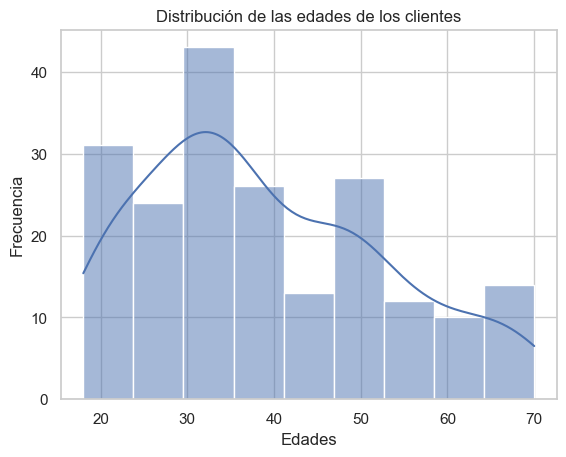

In [3]:
sns.set_theme(style='whitegrid')
sns.histplot(df['Age'], kde=True)

plt.title('Distribución de las edades de los clientes')
plt.xlabel('Edades')
plt.ylabel('Frecuencia')

### 2. ¿Existen diferencias significativas en los ingresos anuales entre hombres y mujeres?
- **Objetivo**: Comparar la distribución de ingresos anuales entre géneros.
- **Respuesta esperada**: Una gráfica de cajas (boxplot) que muestre la distribución de Annual Income (k$) por género.

Female average income 59.25
Male average income 62.22727272727273


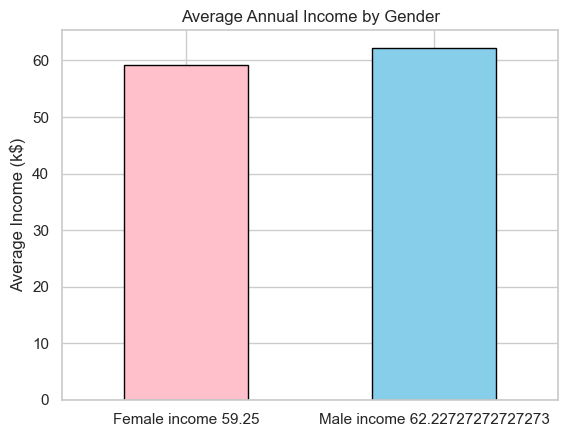

In [4]:
df_male = df[df['Gender'] == 'Male']
male_average_income = df_male['Annual Income'].mean()
df_female = df[df['Gender'] == 'Female']
female_average_income = df_female['Annual Income'].mean()
print(f"Female average income {female_average_income}")
print(f"Male average income {male_average_income}")

averages = pd.Series(
    [female_average_income, male_average_income], 
    index=[f"Female income {female_average_income}", f"Male income {male_average_income}"]
)

# 2. Plot as a bar chart
averages.plot(kind='bar', color=['pink', 'skyblue'], edgecolor='black')

# 3. Add labels and show it
plt.title('Average Annual Income by Gender')
plt.ylabel('Average Income (k$)')
plt.xticks(rotation=0) # Keeps the labels 'Female' and 'Male' horizontal
plt.show()


### 3. ¿Cómo se distribuye la puntuación de gasto (Spending Score) entre los diferentes rangos de edad?
- **Objetivo**: Analizar la relación entre la edad y la puntuación de gasto.
- **Respuesta esperada**: Una gráfica de dispersión (scatter plot) o un gráfico de cajas que compare la Spending Score (1-100) con diferentes grupos de edad.

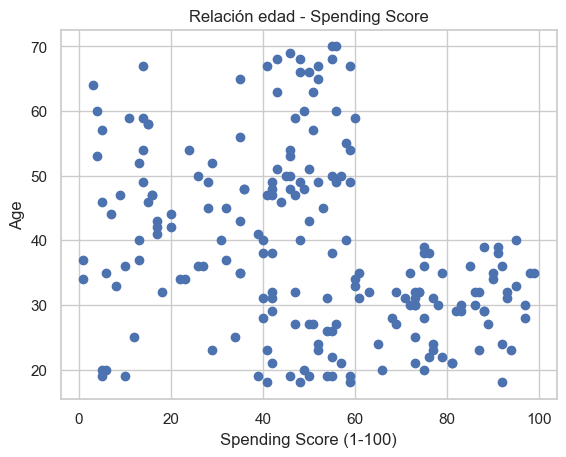

In [5]:
plt.scatter(df['Spending Score'], df['Age'])
plt.title('Relación edad - Spending Score')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Age')
plt.show()

### 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?
- **Objetivo**: Identificar si existe una relación lineal entre el ingreso y el gasto.
- **Respuesta esperada**: Una gráfica de dispersión y el cálculo del coeficiente de correlación entre Annual Income (k$) y Spending Score (1-100).

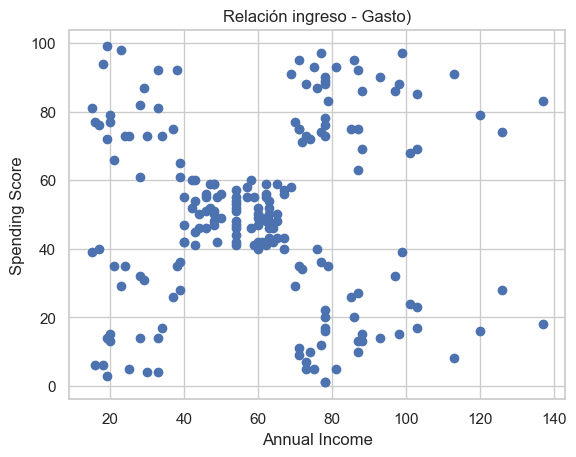

In [6]:
plt.scatter(df['Annual Income'], df['Spending Score']) 
plt.title('Relación ingreso - Gasto)') 
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

### 5. ¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?
- **Objetivo**: Examinar cómo los clientes en diferentes rangos de ingresos se comportan en términos de gasto.
- **Respuesta esperada**: Una gráfica de cajas o de violín que muestre la Spending Score (1-100) para diferentes rangos de Annual Income (k$).

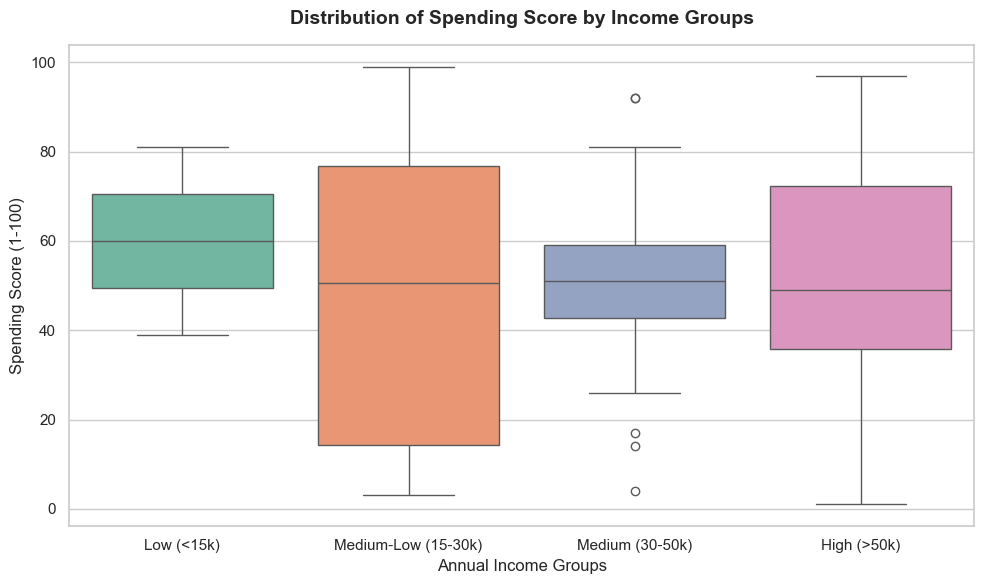

In [7]:
# Generating a new column to group by income
income_bins = [0, 15, 30, 50, 100] 
income_labels = ['Low (<15k)', 'Medium-Low (15-30k)', 'Medium (30-50k)', 'High (>50k)']
df['Income Group'] = pd.cut(df['Annual Income'], bins=income_bins, labels=income_labels, include_lowest=True)
df.sample(5)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Generate the Box Plot
sns.boxplot(
    x='Income Group', 
    y='Spending Score', 
    data=df, 
    palette='Set2',
    hue='Income Group',  # Added hue to avoid future deprecation warnings
    legend=False
)

# 5. Customize the labels and title
plt.title('Distribution of Spending Score by Income Groups', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Annual Income Groups', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)

# 6. Display the plot
plt.tight_layout()
plt.show()

### 6. ¿Cuál es la proporción de clientes por género?
- **Objetivo**: Determinar el balance de género en el conjunto de datos.
- **Respuesta esperada**: Una gráfica de barras o un gráfico de pastel que muestre la proporción de hombres y mujeres.

/var/folders/s9/wr1mc07942ndqxt3cw6qx5f80000gn/T/ipykernel_3430/3341539611.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette=['skyblue', 'pink'], edgecolor='black')


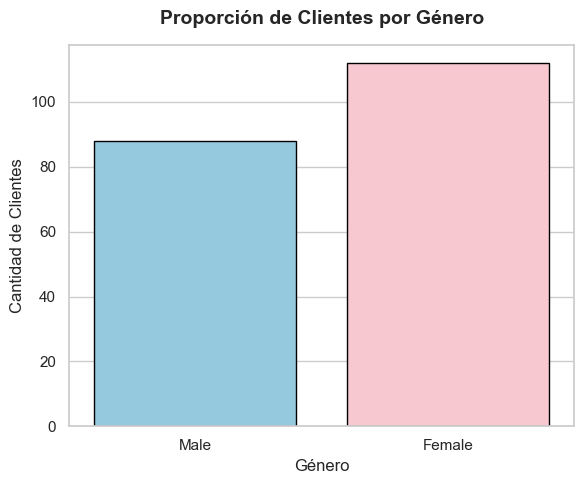

In [8]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 5))

# Create the bar plot (countplot automatically counts the occurrences)
sns.countplot(x='Gender', data=df, palette=['skyblue', 'pink'], edgecolor='black')

# Customize the chart
plt.title('Proporción de Clientes por Género', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Género', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

### 7. ¿Qué grupos de edad gastan más en promedio?
- **Objetivo**: Identificar los grupos de edad que tienen una mayor puntuación de gasto en promedio.
- **Respuesta esperada**: Una gráfica de barras que compare la puntuación de gasto promedio entre diferentes grupos de edad.

  Age Group  Spending Score
1     26-35       64.450000
0     18-25       54.947368
5     66-75       47.250000
2     36-45       44.833333
3     46-55       36.702703
4     56-65       32.117647


/var/folders/s9/wr1mc07942ndqxt3cw6qx5f80000gn/T/ipykernel_3430/1119342278.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_spending = df.groupby('Age Group', as_index=False)['Spending Score'].mean()
/var/folders/s9/wr1mc07942ndqxt3cw6qx5f80000gn/T/ipykernel_3430/1119342278.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_spending, x='Age Group', y='Spending Score', palette='rocket')


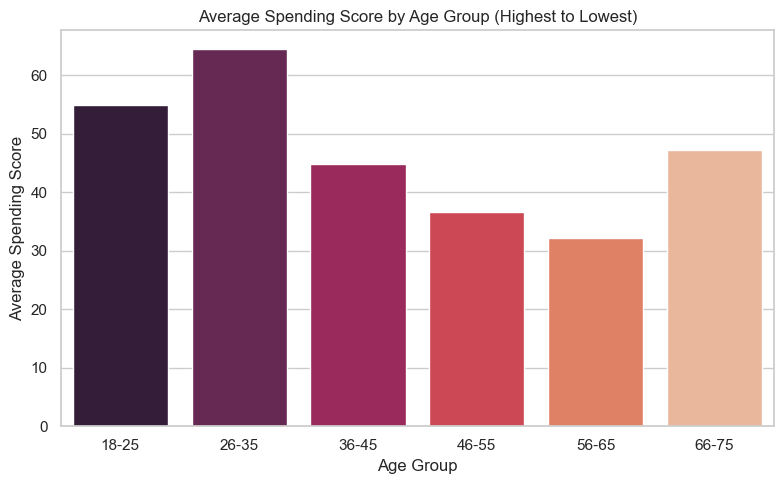

In [33]:
bins = [18, 25, 35, 45, 55, 65, 75]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66-75']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)
avg_spending = df.groupby('Age Group', as_index=False)['Spending Score'].mean()
avg_spending = avg_spending.sort_values(by='Spending Score', ascending=False)
print(avg_spending)
#top_group = avg_spending.iloc[0]
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Plotting the bars sorted by spending score
sns.barplot(data=avg_spending, x='Age Group', y='Spending Score', palette='rocket')

plt.title('Average Spending Score by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Spending Score')
plt.tight_layout()
plt.show()

### 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?
- **Objetivo**: Explorar si hay una tendencia entre la edad de los clientes y sus ingresos.
- **Respuesta esperada**: Una gráfica de dispersión que muestre la relación entre Age y Annual Income (k$).

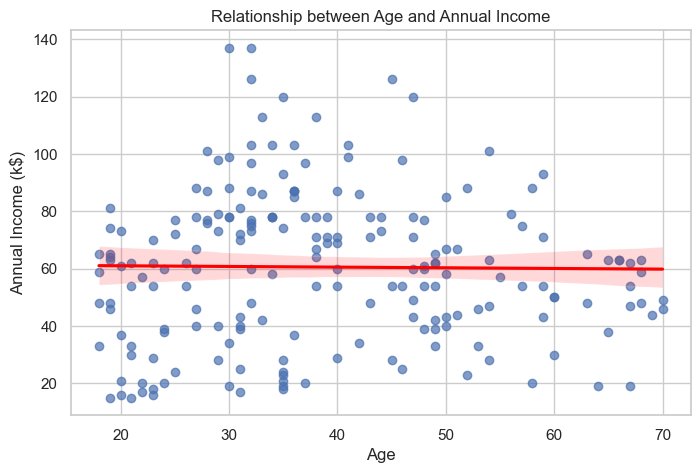

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")

# Create the scatter plot with a trend line
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Age', y='Annual Income', scatter_kws={'alpha':0.7}, line_kws={'color':'red'})

plt.title('Relationship between Age and Annual Income')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show()

### 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?
- **Objetivo**: Entender cómo se distribuyen estas dos variables en conjunto.
- **Respuesta esperada**: Una gráfica de dispersión con una densidad de puntos o un gráfico de hexágonos que muestre la distribución conjunta de Age y Annual Income (k$).

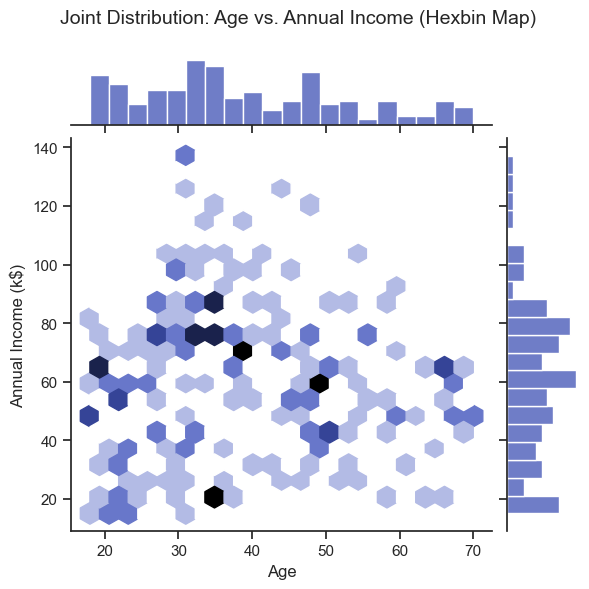

In [35]:
sns.set_theme(style="ticks")

# Create the Hexbin Plot
# 'gridsize' controls how large or small the hexagons are. 
# A larger gridsize means smaller, finer hexagons.
plot = sns.jointplot(
    data=df, 
    x='Age', 
    y='Annual Income', 
    kind='hex', 
    color='#3F51B5', # A nice shade of indigo
    gridsize=20,     # Adjusted for the dataset size
    marginal_kws=dict(bins=20, fill=True) # Customize marginal distributions
)

# Set labels and title
plot.set_axis_labels('Age', 'Annual Income (k$)', fontsize=12)
plt.subplots_adjust(top=0.9) # Make room for the title
plt.suptitle('Joint Distribution: Age vs. Annual Income (Hexbin Map)', fontsize=14)

plt.show()